# Simulation du Transmon 

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
from IPython.display import Image, display
from scipy.optimize import curve_fit
import scipy.constants as sc
path_fig="..//Figures/"
path_Sonnet="..//Sonnet/"

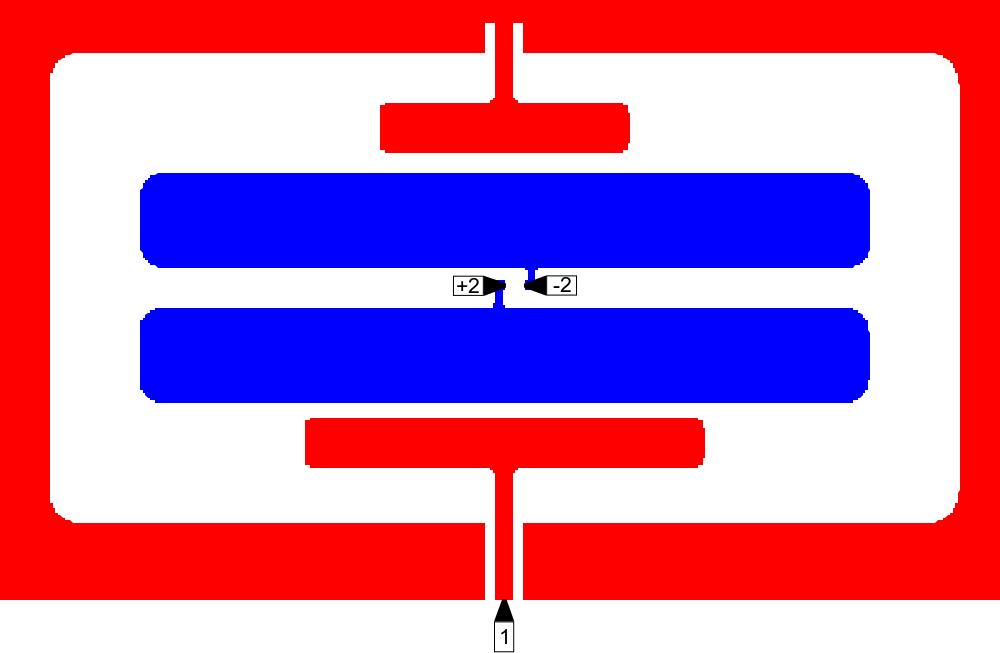

In [9]:
Image(filename=path_fig+"capa.png", width=600)

- Charger le fichier 'Qubit_Capa_2ports.s2p' généré par Sonnet. Ce fichier correspond à une simulation permettant de mesurer la réponse du circuit ci-dessus excité par un signal micro-onde ($0.1 \sim 10 \, \mathrm{GHz}$) injecté au niveau du port $\sharp 1$ couplé capacitivement à la capacité du transmon (rouge) et du port balancés $\sharp \left( \pm 2 \right)$ directement couplé à la capacitédu transmon (bleu). On utilisera pour cela la [bibliothèque skrf](https://scikit-rf.readthedocs.io/en/latest/): on crée une structure rf.Network(path_Sonnet+"Qubit_Capa_2ports.s2p") qui permet d'avoir accès à toutes les [mesures](https://scikit-rf.readthedocs.io/en/latest/tutorials/Networks.html) simulées pae Sonnet.
- Déduire de la simulation la capacité du transmon,
- En déduire l'énergie de charge $E_{\mathrm{c}}$ du transmon,
- Calculer l'énergie Jopehson $E_{\mathrm{J}}$ correspondant à un transmon de fréquence $f_q=f_{01}=3.8 \; \mathrm{GHz}$,
- En déduire les inductances $L_{\mathrm{g}}$ et $L_{\mathrm{e}}$ permettant de simuler le transmon dans l'état fondamental $| g \rangle$ et excité $| e \rangle$.
- Simuler deux [connexions](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.connections_list.html) permettant de coupler la capacité simulée aux inductances  $L_{\mathrm{g}}$ et $L_{\mathrm{e}}$. On créra préalablement 2 [ports](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Port.html), un [ground](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Ground.html) et deux [inductances](https://scikit-rf.readthedocs.io/en/v1.8.0/examples/circuit/Lumped%20Element%20Circuits.html),  Repérer les fréquences de résonance du circuit équilavent.
- On connecte le qubit au résonanteur de lecture à travers la capacité (orange). On simule la réponse à travers le ports 2. Tracer le réfrexion $S_{11}$ au niveau du port 2. Caractériser les résonances obtenues. En nottant $Q_l$ le facteur de qualité du resonateur, on a: $Arg S_{11}=\theta_0+2 \arctan \left[2Q_l\left(\frac{f_r-f}{f_r}\right) \right]$ avec $f_r$ la fréquence de résoance. Déduire des simulations le taux de couplage $\kappa_c$ entre le résonateur et la ligne.
- [Créer deux fichiers](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.network.Network.write_touchstone.html) "Qubit_g.s1p"  et "Qubit_e.s1p" modélisant le qubit dans les états $| g \rangle$ et $| e \rangle$. Ces fichiers seront utilisés pour la simulation de la mesure dispersive du qubit. On n'utilisera deux connexions ne faisant itervenir que le port $\sharp 1$.


### Capacité du transmon

In [10]:
Capa=rf.Network(path_Sonnet+"Qubit_Capa_2ports.s2p")

In [11]:
    Capa.

SyntaxError: invalid syntax (2226516444.py, line 1)

In [ ]:
Capa.z[:,1,1]

In [ ]:
plt.plot(Capa.frequency.f,np.imag(Capa.y[:,1,1]))


Text(0, 0.5, 'Im Y')

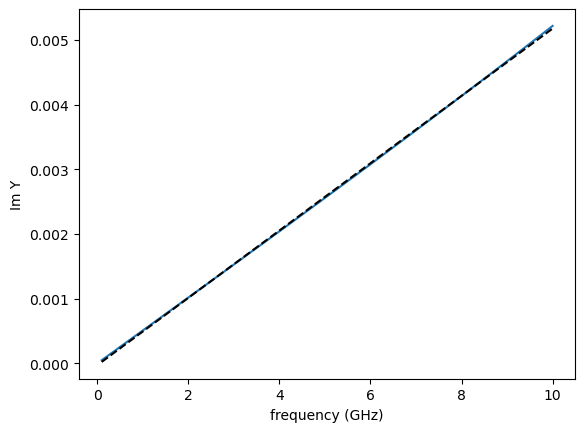

In [12]:
poly=np.polyfit(Capa.frequency.f,Capa.y_im[:,0,0],1)
plt.figure()
plt.plot(1e-9*Capa.frequency.f,Capa.y_im[:,0,0])
plt.plot(1e-9*Capa.frequency.f,np.polyval(poly,Capa.frequency.f),'--k')
plt.xlabel("frequency (GHz)")
plt.ylabel("Im Y")

In [13]:
C=poly[0]/2/np.pi
print("C = "+ str(np.round(C*1e15,2)) +" fF")

C = 82.78 fF


In [14]:
Ec=sc.e**2/(2*C)

In [15]:
print("Ec = " + str(round(Ec/sc.k*1e3,2)) + " mK")

Ec = 11.23 mK


### Energie Josephson du transmon

On déduit de la fréquence $f_q$ du qubit $E_{J}=\frac{\left(E_{c}+hf_q\right)^2}{8E_{c}}$:

In [16]:
fq=3.8e9
Ej=(Ec+sc.h*fq)**2/(8*Ec)

In [17]:
print("Ej = " + str(round(Ej/sc.k*1e3,2)) + " mK")

Ej = 417.22 mK


Le quantum de flux étant $\phi_0=\frac{h}{2e}$, on déduit $L_{J}=\frac{\left(\frac{\phi_0}{2 \pi} \right)^2}{E_{J}}$ et des inductances
$L_g=L_{J} \left( 1+\frac{1}{2} \sqrt{2 \frac{E_c}{E_J}} \right)$
et $L_e=L_{J} \left( 1+\frac{3}{2} \sqrt{\frac{E_c}{E_J}} \right)$


In [18]:
phi0=sc.h/2/sc.e
Lj=(phi0/2/np.pi)**2/(Ej)
Lg=Lj*(1+1/2*np.sqrt(2*Ec/Ej))
Le=Lj*(1+3/2*np.sqrt(Ec/Ej))
print("Zc = " + str(round(np.sqrt(Lg/C))) + " Ohms")
print("Lg = " + str(round(Lg*1e9,2)) + " nH")
print("Le = " + str(round(Le*1e9,2)) + " nH")


Zc = 503 Ohms
Lg = 20.98 nH
Le = 23.43 nH


### Connection des inductances à la capacité du Transmon

On crée des structures inductances ind_g et ind_g simulant le qubit dans son état fondamental $|0\rangle$ et excité $|1\rangle$.

In [19]:
Zc=54.93
freq=Capa.frequency
port1 = rf.Circuit.Port(frequency=freq, name='port1', z0=50)
port2 = rf.Circuit.Port(frequency=freq, name='port2', z0=50)
ground0 = rf.Circuit.Ground(freq, name='GND0')
ind_g = rf.Circuit.SeriesImpedance(frequency=freq, name='ind', z0=Zc,
                                 Z=1j*2*np.pi*freq.f*Lg)
ind_e = rf.Circuit.SeriesImpedance(frequency=freq, name='ind', z0=Zc,
                                 Z=1j*2*np.pi*freq.f*Le)

On réalise les connexions correspondant à l'association en parallèle de la capacité et d'une inductance au niveau des ports balancés $\pm 2$.

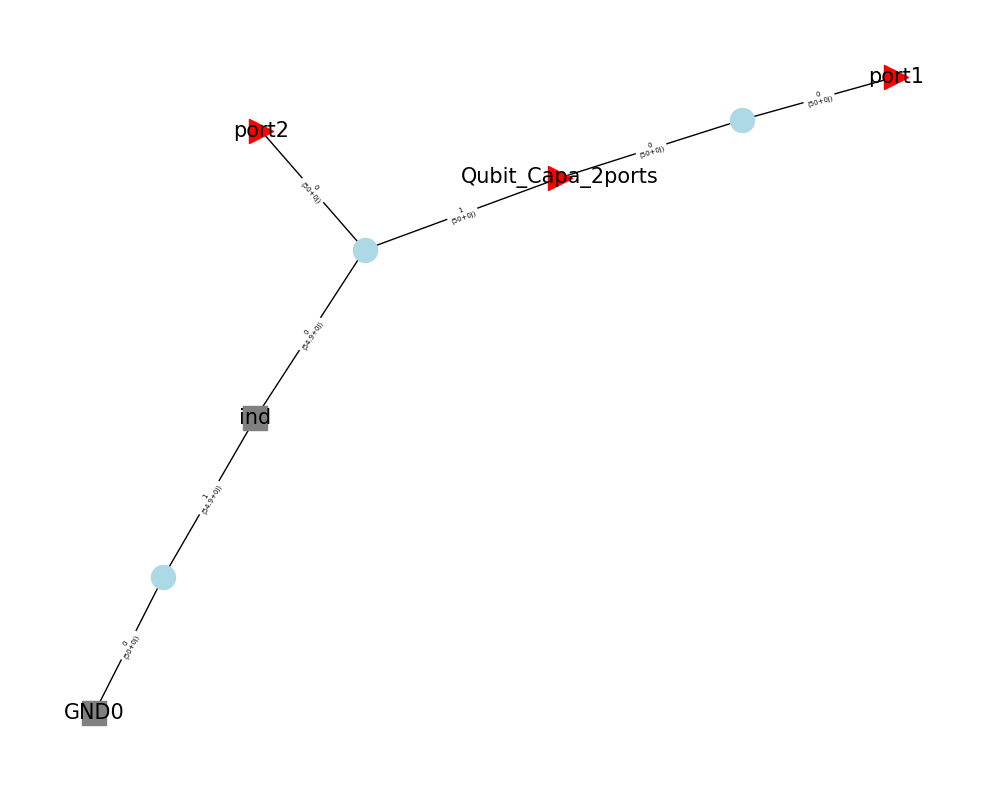

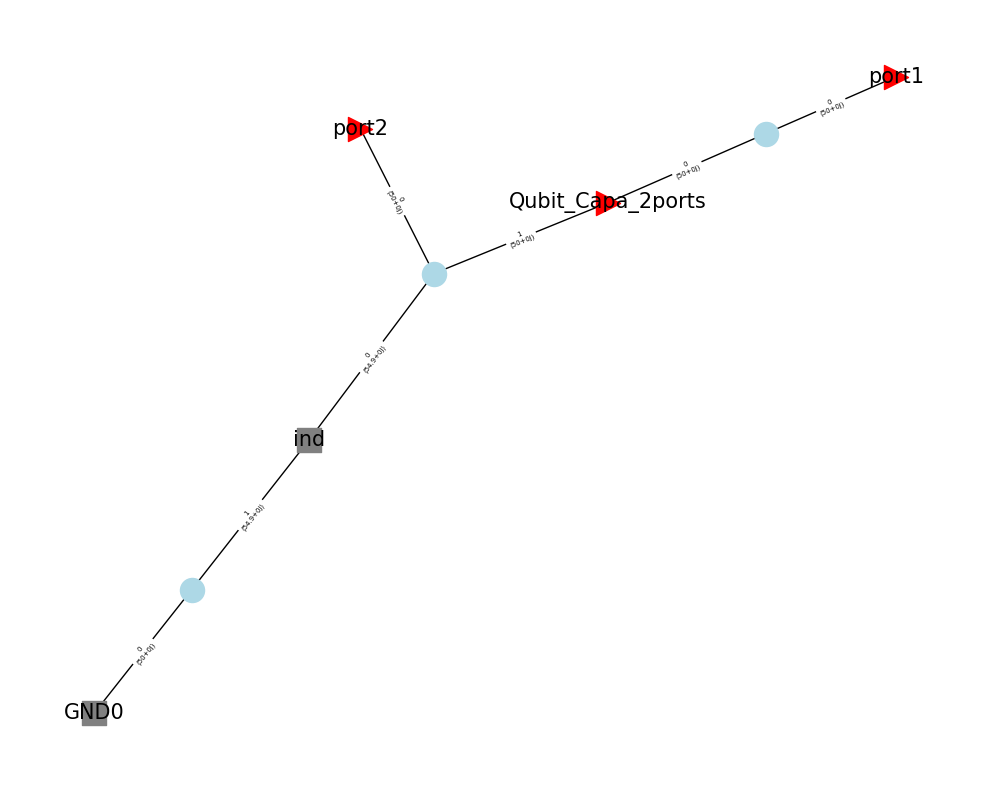

In [20]:
connexion_g=[[(port1, 0), (Capa, 0)],
           [(Capa, 1),(ind_g,0),(port2,0)],
           [(ind_g, 1),(ground0,0)],
          ]
connexion_e=[[(port1, 0), (Capa, 0)],
           [(Capa, 1),(ind_e,0),(port2,0)],
           [(ind_e, 1),(ground0,0)],
          ]
resulting_Circuit_g=rf.Circuit(connexion_g)
resulting_Circuit_e=rf.Circuit(connexion_e)

resulting_Circuit_g.plot_graph(network_labels=True, network_fontsize=15,
               port_labels=True, port_fontsize=15,
              edge_labels=True, edge_fontsize=5)
plt.show()
resulting_Circuit_e.plot_graph(network_labels=True, network_fontsize=15,
               port_labels=True, port_fontsize=15,
              edge_labels=True, edge_fontsize=5)
plt.show()

On cherche les indices des noeuds correspondant aux port 1 et 2

In [21]:
resulting_Circuit_g.port_indexes

[0, 4]

On déduit du coefficient de réflexion $\Gamma$ au niveau du port $\pm 2$ la conductance du résonateur: $Y=\frac{1}{Z_0}\frac{\Gamma-1}{\Gamma+1}$. D'après le théorème de Froster, la fréquence $\omega_{\mathrm{r}}$ de résonance est donnée par $\mathrm{Im} Y(\omega_{\mathrm{r}})=0$. Pour un résonateur LC paralèle: $Y=jC\omega+\frac{1}{jL\omega}$ 

Text(0, 0.5, 'log (Im Y')

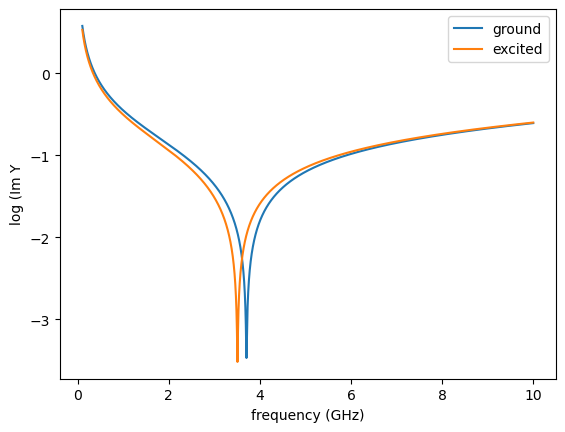

In [22]:
gamma_g=resulting_Circuit_g.s[:,4,4]
gamma_e=resulting_Circuit_e.s[:,4,4]
Y_g=(gamma_g-1)/(gamma_g+1)
Y_e=(gamma_e-1)/(gamma_e+1)
plt.figure()
plt.plot(1e-9*freq.f,np.log10(np.abs(Y_g)), label='ground')
plt.plot(1e-9*freq.f,np.log10(np.abs(Y_e)), label='excited')
plt.legend()
plt.xlabel("frequency (GHz)")
plt.ylabel("log (Im Y")

In [23]:
idx_g=np.argmin(np.log10(np.abs(Y_g)))
idx_e=np.argmin(np.log10(np.abs(Y_e)))
print('fr_g = ' +str(round(freq.f[idx_g]*1e-9,3)) + ' GHz' )
print('fr_e = ' +str(round(freq.f[idx_e]*1e-9,3)) + ' GHz' )

fr_g = 3.704 GHz
fr_e = 3.506 GHz


### Resonances

On regarde l'effet de l'impédance du port 1 sur le facteur de qualité du résonateur.

In [121]:
Zc

54.93

L'impédance caractérinstique du résonateur $\lambda/4$ est $Z_c=\sqrt{L_{\mathrm{eq}}}{C_{\mathrm{eq}}}=\frac{4 Z_{CPW}}{\pi}$ 

In [122]:
2*Zc/np.pi


34.96952409615125

In [105]:
freq=Capa.frequency
port1_34 = rf.Circuit.Port(frequency=freq, name='port1', z0=34.96)
port1_10 = rf.Circuit.Port(frequency=freq, name='port1', z0=10)
port1_20 = rf.Circuit.Port(frequency=freq, name='port1', z0=20)
port1_30 = rf.Circuit.Port(frequency=freq, name='port1', z0=30)
port1_40 = rf.Circuit.Port(frequency=freq, name='port1', z0=40)
port1_50 = rf.Circuit.Port(frequency=freq, name='port1', z0=54.93)
ground0 = rf.Circuit.Ground(freq, name='GND0')
ind_g = rf.Circuit.SeriesImpedance(frequency=freq, name='ind', z0=Zc,
                                 Z=1j*2*np.pi*freq.f*19.15e-9)


In [109]:
connexion_34=[[(port1_34, 0), (Capa, 0)],
           [(Capa, 1),(ind_g,0)],
           [(ind_g, 1),(ground0,0)],
          ]
connexion_10=[[(port1_10, 0), (Capa, 0)],
           [(Capa, 1),(ind_g,0)],
           [(ind_g, 1),(ground0,0)],
          ]
connexion_20=[[(port1_20, 0), (Capa, 0)],
           [(Capa, 1),(ind_g,0)],
           [(ind_g, 1),(ground0,0)],
          ]
connexion_30=[[(port1_30, 0), (Capa, 0)],
           [(Capa, 1),(ind_g,0)],
           [(ind_g, 1),(ground0,0)],
          ]

connexion_40=[[(port1_40, 0), (Capa, 0)],
           [(Capa, 1),(ind_g,0)],
           [(ind_g, 1),(ground0,0)],
          ]

connexion_50=[[(port1_50, 0), (Capa, 0)],
           [(Capa, 1),(ind_g,0)],
           [(ind_g, 1),(ground0,0)],
          ]
resulting_Circuit_34=rf.Circuit(connexion_34)
resulting_Circuit_10=rf.Circuit(connexion_10)
resulting_Circuit_20=rf.Circuit(connexion_20)
resulting_Circuit_30=rf.Circuit(connexion_30)
resulting_Circuit_40=rf.Circuit(connexion_40)
resulting_Circuit_50=rf.Circuit(connexion_50)


(3.8, 3.95)

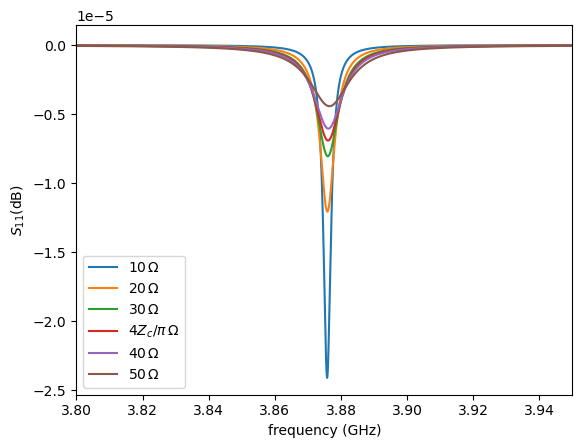

In [113]:
plt.figure()
plt.plot(1e-9*freq.f,np.log10(np.abs(resulting_Circuit_10.s[:,0,0])), label='$10 \,\Omega$')
plt.plot(1e-9*freq.f,np.log10(np.abs(resulting_Circuit_20.s[:,0,0])), label='$20 \,\Omega$')
plt.plot(1e-9*freq.f,np.log10(np.abs(resulting_Circuit_30.s[:,0,0])), label='$30 \, \Omega$')
plt.plot(1e-9*freq.f,np.log10(np.abs(resulting_Circuit_34.s[:,0,0])), label='$4 Z_c/\pi \, \Omega$')
plt.plot(1e-9*freq.f,np.log10(np.abs(resulting_Circuit_40.s[:,0,0])), label='$40 \, \Omega$')
plt.plot(1e-9*freq.f,np.log10(np.abs(resulting_Circuit_50.s[:,0,0])), label='$50 \, \Omega$')
plt.xlabel("frequency (GHz)")
plt.ylabel("$S_{11} (\mathrm{dB})$")
plt.legend()
plt.xlim(3.8,3.95)

Text(0, 0.5, '$\\mathrm{Arg S_{11}}$')

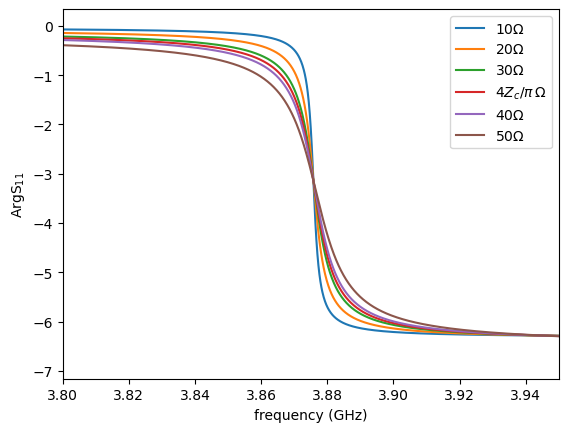

In [115]:
plt.figure()

plt.plot(1e-9*freq.f,np.unwrap(np.angle(resulting_Circuit_10.s[:,0,0])), label='$10 \Omega$')
plt.plot(1e-9*freq.f,np.unwrap(np.angle(resulting_Circuit_20.s[:,0,0])), label='$20 \Omega$')
plt.plot(1e-9*freq.f,np.unwrap(np.angle(resulting_Circuit_30.s[:,0,0])), label='$30 \Omega$')
plt.plot(1e-9*freq.f,np.unwrap(np.angle(resulting_Circuit_34.s[:,0,0])), label='$4 Z_c/\pi \, \Omega$')
plt.plot(1e-9*freq.f,np.unwrap(np.angle(resulting_Circuit_40.s[:,0,0])), label='$40 \Omega$')
plt.plot(1e-9*freq.f,np.unwrap(np.angle(resulting_Circuit_50.s[:,0,0])), label='$50 \Omega$')
plt.xlim(3.8,3.95)
plt.legend()
plt.xlabel("frequency (GHz)")
plt.ylabel("$\mathrm{Arg S_{11}}$")


### Fit de la résonance

In [86]:
# Define the  fitting function
def quality(f,theta0,Q,fr):
    y = theta0+2*np.atan(2*Q*(1-f/fr))
    return y

In [87]:
freq.f

array([1.0000e+08, 1.0010e+08, 1.0020e+08, ..., 9.9998e+09, 9.9999e+09,
       1.0000e+10], shape=(99001,))

In [116]:
Fit=np.zeros(shape=(6,3))
init = [0,10000,3.8e9]  
Fit[0,:], covar =curve_fit(quality,freq.f,np.unwrap(np.angle(resulting_Circuit_10.s[:,0,0])), p0=init,bounds=([-5,100,3e9], [1,1e5,4e9]))
Fit[1,:], covar =curve_fit(quality,freq.f,np.unwrap(np.angle(resulting_Circuit_20.s[:,0,0])), p0=init,bounds=([-5,100,3e9], [1,1e5,4e9]))
Fit[2,:], covar =curve_fit(quality,freq.f,np.unwrap(np.angle(resulting_Circuit_30.s[:,0,0])), p0=init,bounds=([-5,100,3e9], [1,1e5,4e9]))
Fit[3,:], covar =curve_fit(quality,freq.f,np.unwrap(np.angle(resulting_Circuit_34.s[:,0,0])), p0=init,bounds=([-5,100,3e9], [1,1e5,4e9]))
Fit[4,:], covar =curve_fit(quality,freq.f,np.unwrap(np.angle(resulting_Circuit_40.s[:,0,0])), p0=init,bounds=([-5,100,3e9], [1,1e5,4e9]))
Fit[5,:], covar =curve_fit(quality,freq.f,np.unwrap(np.angle(resulting_Circuit_50.s[:,0,0])), p0=init,bounds=([-5,100,3e9], [1,1e5,4e9]))


In [117]:
f0=np.zeros(shape=(6,1))
kappa=np.zeros(shape=(6,1))

for k in range(0,6):
    f0[k]=Fit[k,2]
    kappa[k]=2*np.pi*Fit[k,2]/Fit[k,1]


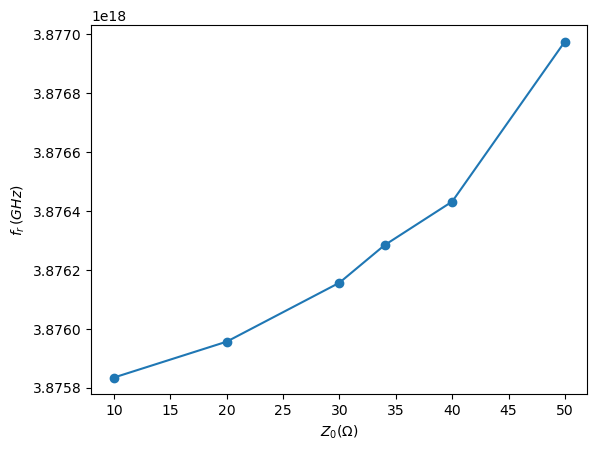

In [118]:
plt.figure()
plt.plot([10,20,30,34,40,50],1e9*f0, marker='o', linestyle='-')
plt.xlabel("$Z_0 (\Omega)$")
plt.ylabel("$f_r \, (GHz)$")
#plt.ylim(400, 500)
plt.show()   

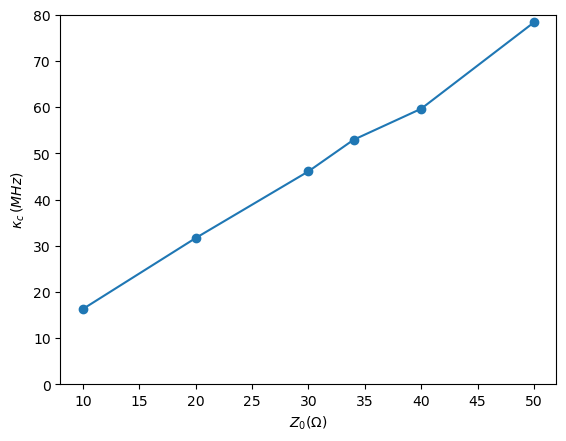

In [119]:
plt.figure()
plt.plot([10,20,30,34,40,50],1e-6*kappa, marker='o', linestyle='-')
plt.xlabel("$Z_0 (\Omega)$")
plt.ylabel("$\kappa_c \, (MHz)$")
plt.ylim(0, 80)
plt.show()   

In [120]:
print('f0 = ' + str(np.round(1e-9*Fit[3,2],3)) + ' GHz')
print('kappa = ' + str(np.round(1e-6*2*np.pi*Fit[3,2]/Fit[3,1],3)) + ' MHz')


f0 = 3.876 GHz
kappa = 52.924 MHz


### Fichiers s1p pour la simulation de la mesure 

In [97]:
port1 = rf.Circuit.Port(frequency=freq, name='port1', z0=54.93)

In [98]:
connexion_g=[[(port1, 0), (Capa, 0)],
           [(Capa, 1),(ind_g,0)],
           [(ind_g, 1),(ground0,0)],
          ]
connexion_e=[[(port1, 0), (Capa, 0)],
           [(Capa, 1),(ind_e,0)],
           [(ind_e, 1),(ground0,0)],
          ]


In [99]:
DUT_g=resulting_Circuit_g.s[:,0,0]
DUT_e=resulting_Circuit_e.s[:,0,0]
DUT_struct_g= rf.Network(frequency=freq, s=DUT_g, z0=Zc ,name='Qubit_g')
DUT_struct_e= rf.Network(frequency=freq, s=DUT_e, z0=Zc ,name='Qubit_e')
DUT_struct_g.write_touchstone(filename='Qubit_g', dir='.')
DUT_struct_e.write_touchstone(filename='Qubit_e', dir='.')